# IEEE Fraud Detection — Exploratory Data Analysis(EDA)


In this notebook, we perform **Exploratory Data Analysis (EDA)** on the IEEE Fraud Detection dataset.

The goal of this step is to **understand the data and identify patterns related to fraudulent transactions**.
At this stage, we are not building any machine learning models. Instead, we focus on exploring the dataset and understanding how different features behave.

EDA helps us discover useful insights that will guide **data preprocessing, feature engineering, and model building** in the later stages of the project.

## What We Will Do in This Notebook

In this notebook, we will perform the following analyses:

1. Analyze the distribution of fraud and non-fraud transactions.
2. Explore the distribution of transaction amounts.
3. Compare transaction amounts for fraud vs non-fraud cases.
4. Analyze fraud patterns across different product categories.
5. Explore card-related features and their relationship with fraud.
6. Examine device-related information and its impact on fraud.
7. Analyze transaction time patterns.
8. Explore correlations between important numerical features.

## Why This Step Is Important

Exploratory Data Analysis helps us:

* Understand how the dataset is structured
* Identify patterns in fraudulent transactions
* Detect unusual behavior or outliers
* Find features that may help machine learning models detect fraud

These insights will help us design a **better fraud detection model** in the next steps of the project.



In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
trans = pd.read_csv('/content/train_transaction.csv')
ident = pd.read_csv('/content/train_identity.csv')

In [43]:
trans.head(2)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
ident.head(2)

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device


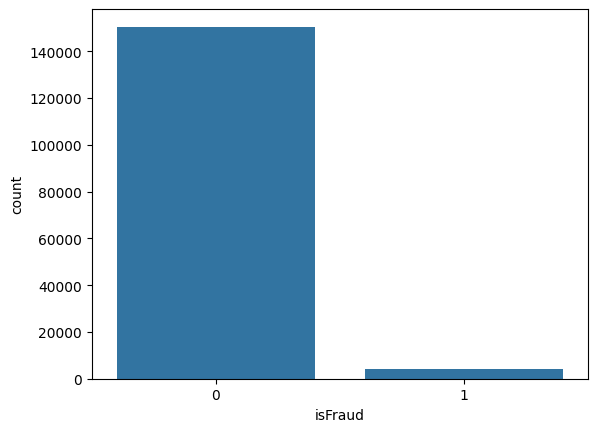

In [42]:
## Target Analysis

sns.countplot(x='isFraud' , data= trans)
plt.show()

### Observations

* The dataset contains significantly more normal transactions than fraudulent ones.
* Fraud transactions represent only a small percentage of the dataset.
* This indicates a **class imbalance problem**, which is common in fraud detection tasks.


In [45]:
## transaction amount analysis

trans['TransactionAmt'].describe()

,TransactionAmt
count,154598.000000
mean,128.382836
std,201.096644
min,0.292000
25%,44.000000
50%,75.000000
75%,128.886250
max,5094.950000


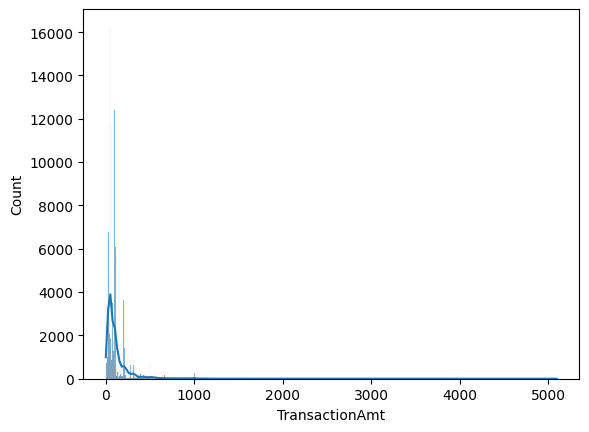

In [46]:
sns.histplot(trans['TransactionAmt'],kde=True)
plt.show()

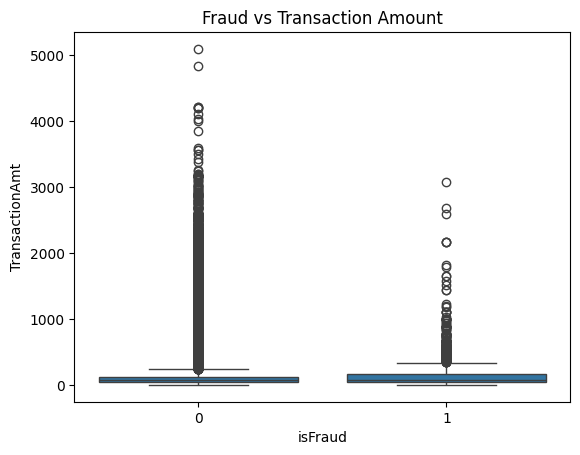

In [49]:
sns.boxplot(x='isFraud', y='TransactionAmt', data=trans)
plt.title("Fraud vs Transaction Amount")
plt.show()

### Observations

* Most transactions occur at lower transaction amounts.
* Both normal and fraudulent transactions are concentrated in the lower amount range.
* Fraud transactions show higher variability and include several high-value outliers.
* The distribution of transaction amounts is right-skewed.
* Transaction amount alone may not fully distinguish fraud, but extreme values could indicate suspicious activity.


In [51]:
## product Distribution
trans['ProductCD'].value_counts()

,count
ProductCD,
W,89640
H,21626
R,21021
C,19028
S,3283


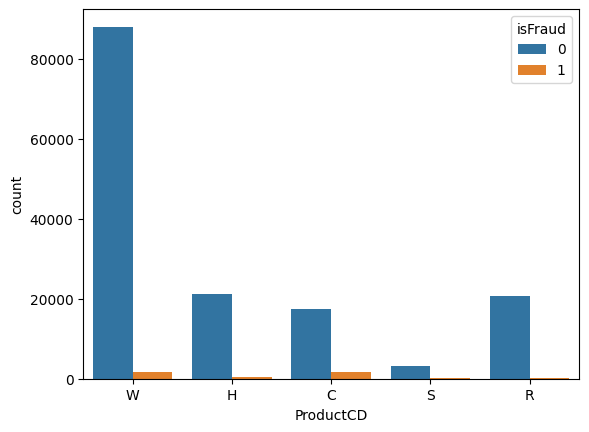

In [52]:
sns.countplot(x='ProductCD' , hue='isFraud' , data=trans)
plt.show()

In [54]:
trans.groupby('ProductCD')['isFraud'].mean()

,isFraud
ProductCD,
C,0.086609
H,0.021132
R,0.012702
S,0.035029
W,0.018396


### Observations

The fraud rate varies across different product categories.

* Product **C** has the highest fraud rate (~8.66%), indicating that transactions in this category are more likely to be fraudulent.
* Product **S** also shows a relatively higher fraud rate compared to other categories.
* Product **R** has the lowest fraud rate (~1.27%).
* This suggests that the product category may provide useful signals for identifying fraudulent transactions.


In [56]:
#Card Type Distribution

trans['card4'].value_counts()

,count
card4,
visa,101404
mastercard,46455
american express,4617
discover,2114


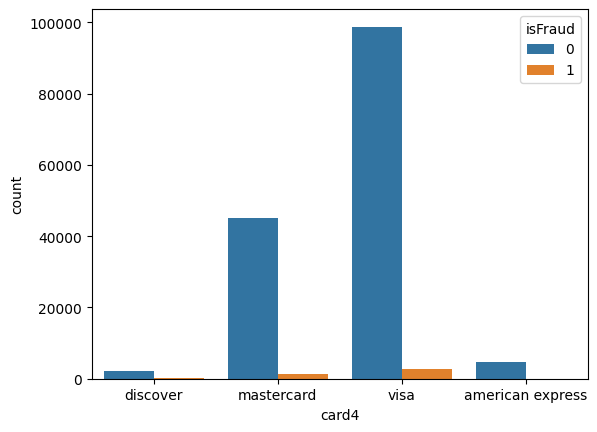

In [57]:
sns.countplot(x='card4' , hue='isFraud' , data=trans)
plt.show()

In [58]:
trans.groupby('card4')['isFraud'].mean()

,isFraud
card4,
american express,0.011046
discover,0.033586
mastercard,0.029921
visa,0.025857


### Observations

The majority of transactions are made using Visa cards, followed by Mastercard. American Express and Discover cards represent a smaller portion of the dataset.

Fraudulent transactions occur across all card networks. However, the fraud rate varies between card types.

Discover cards show the highest fraud rate, followed by Mastercard and Visa. American Express shows the lowest fraud rate.

This suggests that card network information may provide useful signals for identifying fraudulent transactions.


In [61]:
## Device Type Distribution
ident['DeviceType'].value_counts()


,count
DeviceType,
desktop,85165
mobile,55645


In [63]:
df = trans.merge(ident, on='TransactionID', how='left')

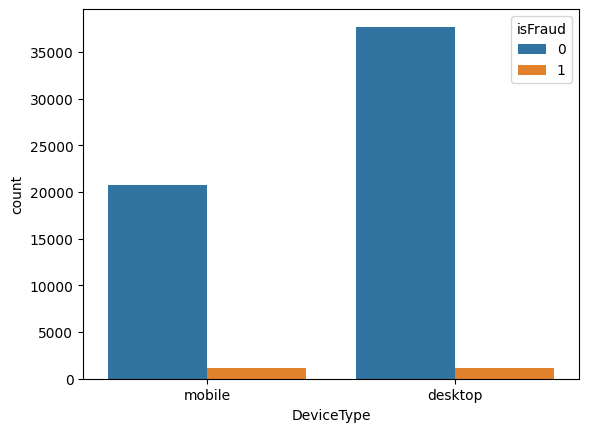

In [66]:
sns.countplot(x='DeviceType' , hue='isFraud' , data = df)
plt.show()

In [67]:
df.groupby('DeviceType')['isFraud'].mean()

,isFraud
DeviceType,
desktop,0.029440
mobile,0.054487


### Observations

Fraud rates differ significantly between device types.

* Mobile devices show a fraud rate of approximately 5.45%.
* Desktop devices show a lower fraud rate of approximately 2.94%.

This indicates that transactions performed on mobile devices are more likely to be fraudulent compared to desktop transactions.

Device type may therefore serve as an important behavioral signal in fraud detection models.


In [68]:
df['TransactionDT']

,TransactionDT
0,86400
1,86401
2,86469
3,86499
4,86506
...,...
154593,3194246
154594,3194255
154595,3194265
154596,3194270


In [71]:
df['hour'] = ((df['TransactionDT'] / 3600) % 24).astype(int)

In [73]:
df.hour.value_counts().sort_values(ascending=False)

,count
hour,
19,11541
18,11365
17,11264
21,11215
20,11053
16,10551
22,10451
23,10088
0,9525


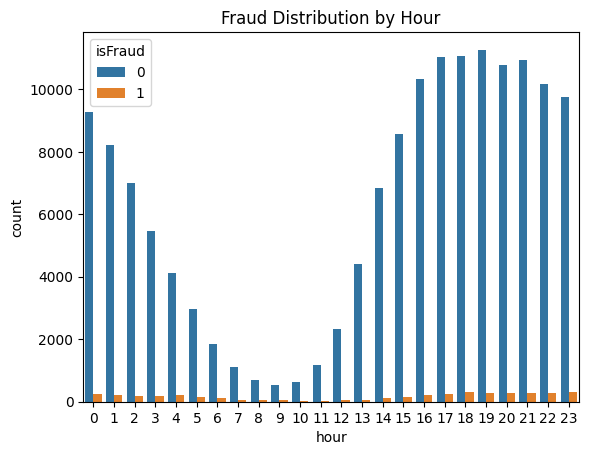

In [74]:
sns.countplot(x='hour', hue='isFraud', data=df)
plt.title("Fraud Distribution by Hour")
plt.show()

### Observations

Transaction activity varies throughout the day. The majority of transactions occur during the afternoon and evening hours.

Fraudulent transactions follow a similar pattern and tend to increase during periods of higher transaction activity.

This suggests that fraudulent behavior often occurs during peak transaction hours when overall activity is higher.


In [75]:
cols = [
'isFraud',
'TransactionAmt',
'card1',
'card2',
'addr1',
'addr2',
'hour'
]

In [76]:
corr = df[cols].corr()
corr

,isFraud,TransactionAmt,card1,card2,addr1,addr2,hour
isFraud,1.000000,0.006728,-0.024950,-0.003664,-0.007210,-0.066095,-0.016147
TransactionAmt,0.006728,1.000000,-0.007348,0.013593,-0.013043,0.051345,0.046279
card1,-0.024950,-0.007348,1.000000,-0.001980,0.019555,-0.002924,-0.001131
card2,-0.003664,0.013593,-0.001980,1.000000,0.026316,-0.028471,0.002628
addr1,-0.007210,-0.013043,0.019555,0.026316,1.000000,-0.012651,-0.005149
addr2,-0.066095,0.051345,-0.002924,-0.028471,-0.012651,1.000000,0.022931
hour,-0.016147,0.046279,-0.001131,0.002628,-0.005149,0.022931,1.000000


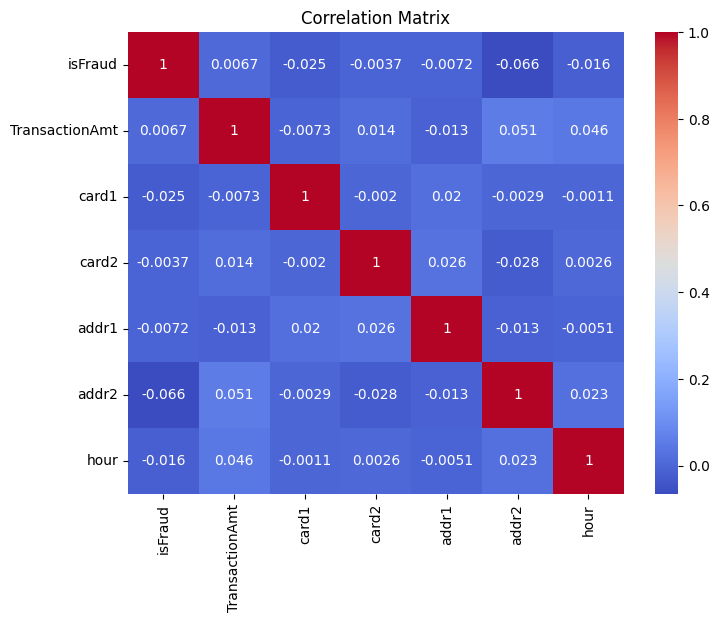

In [78]:


plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Observations

The correlation matrix shows that individual features have very weak correlations with the target variable (`isFraud`). This indicates that fraudulent transactions cannot be identified using a single feature alone.

Fraud detection typically relies on complex patterns that involve multiple behavioral signals such as transaction amount, device information, transaction time, and product type.

Additionally, most features show low correlation with each other, suggesting minimal multicollinearity among the selected variables.


## Exploratory Data Analysis (EDA) — Summary

In this section, we explored the transaction and identity datasets to understand the structure of the data and identify potential fraud patterns.

### Key Findings

**1. Fraud Distribution**

* The dataset is highly imbalanced.
* Fraudulent transactions represent a very small portion of the dataset (~2–3%).

**2. Transaction Amount**

* Transaction amounts are heavily right-skewed.
* Most transactions are small, but some high-value outliers exist.
* Fraudulent transactions show higher variability in transaction amounts.

**3. Product Type Analysis**

* Fraud rates vary across product categories.
* Product **C** shows the highest fraud rate compared to other categories.

**4. Card Network Analysis**

* Visa and Mastercard dominate the dataset in terms of transaction volume.
* Discover cards show a relatively higher fraud rate.

**5. Device Type Analysis**

* Desktop transactions are more frequent than mobile transactions.
* However, mobile transactions show a significantly higher fraud rate (~5.4%) compared to desktop (~2.9%).

**6. Time-Based Analysis**

* Transaction activity increases during afternoon and evening hours.
* Fraudulent transactions tend to follow overall transaction activity patterns.

**7. Correlation Analysis**

* Individual features show weak correlation with the fraud label.
* Fraud detection likely depends on complex interactions between multiple features rather than a single variable.

### Conclusion

The exploratory analysis suggests that fraud detection requires combining multiple behavioral signals such as transaction amount, device information, product category, card network, and transaction timing. These insights will guide the next stages of the project, including feature engineering and model development.
